In [572]:
import optuna
from collections.abc import Callable, Iterable, Sequence
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import pickle

optuna.logging.set_verbosity(optuna.logging.ERROR)
orig_settings = np.seterr(all='raise', over='ignore', under='ignore')


SAVE_FILENAME = 'analitic_results.csv'

In [573]:
class PolynomialCoefsMod2:
    def __init__(self, *coefs: float, max_x=1., eps=1e-100, offset = 0, verbose=False):
        self.eps = eps
        self.max_x = max_x
        self.max_sqr_x = max_x * max_x
        self.offset = offset
        self.verbose = verbose
        if isinstance(coefs[0], PolynomialCoefsMod2):
            self._coefs = coefs[0]._coefs
        else:
            self._coefs = np.array([0.], dtype=np.longdouble)
            self.coefs = coefs
        self.normalize()
    def tell(self, s: str):
        if self.verbose:
            print(s)
    def is_pos_infty(self):
        return (self._coefs == float('+inf')).any()
    def is_neg_infty(self):
        return (self._coefs == float('-inf')).any()
    def to_pos_infty(self):
        self._coefs = np.array([float('inf')])
        self.offset %= 2
    def to_neg_infty(self):
        self._coefs = np.array([float('-inf')])
        self.offset %= 2
    def normalize(self, eps: float | None = None):
        self.tell('normalize')
        if self.is_pos_infty():
            self.to_pos_infty()
            return
        if self.is_neg_infty():
            self.to_neg_infty()
            return
        if eps is None:
            eps = self.eps
        x = 1
        for i, coef in enumerate(self.coefs):
            try:
                if abs(coef * x) <= abs(eps):
                    self.coefs[i] = 0
            except OverflowError as e:
                print(f"coef = {coef}")
                print(f"x = {x}")
                print(e)
                raise e
            except FloatingPointError as e:
                print(f"coef = {coef}")
                print(f"x = {x}")
                print(e)
                raise e
            x *= self.max_sqr_x
        k_begin = 0
        for coef in self.coefs:
            if coef != 0:
                break
            k_begin += 1
        if k_begin == len(self.coefs):
            k_begin = len(self.coefs)-1
        self.offset += k_begin*2
        self._coefs = self._coefs[k_begin:]
        k_end = len(self.coefs)
        for coef in reversed(self.coefs):
            if coef != 0:
                break
            k_end -= 1
        if k_end == 0:
            k_end = 1
        self._coefs = self._coefs[:k_end]
    def copy(self):
        self.tell('copy')
        return PolynomialCoefsMod2(*self.coefs,
                                  max_x=self.max_x,
                                  eps=self.eps,
                                  offset=self.offset,
                                  verbose=self.verbose,
        )
    @property
    def coefs(self):
        return self._coefs
    @coefs.setter
    def coefs(self, value):
        if isinstance(value, (list, tuple)):
            self._coefs = np.asarray(value)
        else:
            raise TypeError
    def __setitem__(self, key: int | slice, value):
        self.tell('__setitem__')
        if isinstance(key, int):
            if key < self.offset:
                raise IndexError
            key -= self.offset
            if key >= len(self._coefs):
                raise IndexError
            if key % 2 != 0:
                raise IndexError
            self._coefs[key] = value
        elif isinstance(key, slice):
            self._coefs[key] = value
        else:
            raise TypeError
    def __getitem__(self, key):
        self.tell('__getitem__')
        if isinstance(key, int):
            if key < self.offset:
                return 0
            key -= self.offset
            if key >= len(self._coefs):
                return 0
            if key % 2 != 0:
                return 0
            key //= 2
            return self._coefs[key]
        elif isinstance(key, slice):
            return self._coefs[key]
        else:
            raise TypeError
    def __call__(self, x):
        self.tell('__call__')
        if self.is_pos_infty():
            return float('+inf')
        if self.is_neg_infty():
            return float('-inf')
        try:
            cur_x = x ** self.offset
            result = self._coefs[0] * cur_x
            x_sqr = x * x
            for coef in self._coefs[1:]:
                cur_x *= x_sqr
                result += cur_x * coef
            return result
        except Exception as e:
            print(e)
            return float('+inf')
    def __len__(self):
        return len(self._coefs)
    def __repr__(self):
        res = '0'
        if (self.offset == 0) and (self._coefs[0] != 0):
            res = f'{self._coefs[0]}'
        elif (self.offset == 1) and (self._coefs[0] != 0):
            res = f'{self._coefs[0]}x'
        else:
            res = f"{self._coefs[0]}x^{self.offset}"
        for i, coef in enumerate(self._coefs[1:]):
            if coef != 0:
                res += f"+{coef}x^{2*(i+1)+self.offset}"
        return res
    def __iadd__(self, other):
        self.tell('__iadd__')
        if isinstance(other, PolynomialCoefsMod2):
            if self.offset % 2 != other.offset % 2:
                raise TypeError(f"Это полиномы разной чётности!\n\tp1={self}\n\tp2={other}")
            self_min = self.offset
            self_max = self.offset + len(self._coefs) * 2
            other_min = other.offset
            other_max = other.offset + len(other._coefs) * 2
            bias = min(self_min, other_min)
            self_min -= bias
            self_max -= bias
            other_min -= bias
            other_max -= bias
            self_min //= 2
            self_max //= 2
            other_min //= 2
            other_max //= 2
            new_coefs = np.zeros(max(self_max, other_max))
            try:
                new_coefs[self_min : self_max] += self._coefs
                new_coefs[other_min : other_max] += other._coefs
                self._coefs = new_coefs
                self.offset = bias
            except:
                self.to_pos_infty()
            return self    
        elif isinstance(other, int | float):
            self._coefs[0] += other
            return self
        else:
            raise TypeError
    def __add__(self, other):
        self.tell('__add__')
        res = self.copy()
        res += other
        return res
    def __imul__(self, other):
        self.tell('__imul__')
        if isinstance(other, PolynomialCoefsMod2):
            self.offset += other.offset
            new_len = len(other) + len(self) - 1
            ans = np.zeros(new_len)
            for i, coef in enumerate(other._coefs):
                try:
                    ans[i:i+len(self)] += coef * self._coefs
                except FloatingPointError as e:
                    print(e)
                    print(f"coef={coef}")
                    print(f"self._coefs={self._coefs}")
                    self.to_pos_infty()
                    break
                    raise e
            else:
                self._coefs = ans
                self.normalize()
            return self
        elif isinstance(other, (int, float)):
            self._coefs = self._coefs * other
            return self
        else:
            raise TypeError(f"other={other} has type {type(other)}")
    def __mul__(self, other):
        self.tell('__mul__')
        ans = self.copy()
        ans *= other
        return ans
    def __idiv__(self, other):
        self.tell('__idiv__')
        if isinstance(other, (int, float)):
            self._coefs /= other
            return self
        else:
            raise TypeError(f"other={other} has type {type(other)}")
    def __ipow__(self, other):
        self.tell('__ipow__')
        if isinstance(other, int):
            if other == 0:
                self._coefs = np.array([1])
                self.offset = 0
                return self
            if other == 1:
                return self
            if other % 2 == 0:
                self **= other // 2
                self *= self
            else:
                remember = self.copy()
                self **= other // 2
                self *= self
                self *= remember
            return self
        else:
            raise TypeError
    def __pow__(self, other):
        self.tell('__pow__')
        res = self.copy()
        res **= other
        return res
    def composition(self, other):
        self.tell('composition')
        if isinstance(other, PolynomialCoefsMod2):
            cur_x = other ** self.offset
            result = cur_x * self._coefs[0]
            other_sqr = other.copy()
            other_sqr **= 2
            for coef in self._coefs[1:]:
                cur_x *= other_sqr
                result += cur_x * coef
            result.normalize()
            return result
        else:
            raise TypeError
    def __ilshift__(self, other):
        if isinstance(other, int):
            if other == 0:
                self._coefs = np.array([0, 1])
                return self
            if other == 1:
                return self
            if other % 2 == 0:
                self <<= other // 2
                self = self.composition(self)
            else:
                remember = self.copy()
                self <<= other // 2
                self = self.composition(self)
                self = remember.composition(self)
            self.normalize()
            return self
        else:
            raise TypeError()
    def self_integrate(self):
        self._coefs /= 2 * np.arange(len(self._coefs)) + 1 + self.offset
        self.offset += 1
        return self
    def integrate(self):
        ret = self.copy()
        ret.self_integrate()
        return ret
    def l2_metric_with_1(self, l: float = 1):
        try:
            I1 = l
            I2 = self.integrate()(l)
            tmp = self.copy()
            tmp **= 2
            I3 = tmp.self_integrate()(l)
            l2 = I1 - 2 * I2 + I3
            l2 = round(l2, 4)
            return l2 ** 0.5
        except Exception as e:
            print(l)
            print(f"offset={self.offset}")
            print(f"L2={l2}")
            print(self.coefs)
            print(tmp.coefs)
            raise e
            return float('+inf')


## Tests

In [574]:
a = PolynomialCoefsMod2(1.,1,)
a

1.0+1.0x^2

In [575]:
a = PolynomialCoefsMod2(1.,1,)
print("a =", a)
b = PolynomialCoefsMod2(1.,1, 1e-10)
print("b =", b)
b + a

a = 1.0+1.0x^2
b = 1.0+1.0x^2+1e-10x^4


2.0+2.0x^2+1e-10x^4

In [576]:
a = PolynomialCoefsMod2(0.,1)
print("a =", a)
a **= 2
a

a = 1.0x^2


1.0x^4

In [577]:
a = PolynomialCoefsMod2(0.,0,0,1,1)
print("a =", a)
b = PolynomialCoefsMod2(0.,1,1, 1e-100)
print("b =", b)
a *= b
a

a = 1.0x^6+1.0x^8
b = 1.0x^2+1.0x^4


1.0x^8+2.0x^10+1.0x^12

In [578]:
a = PolynomialCoefsMod2(0.,1,1)
a **= 0
a

1

In [579]:
a = PolynomialCoefsMod2(1.)
print("a =", a)
b = PolynomialCoefsMod2(0.,0,1, verbose=True)
print("b =", b)
a + b

a = 1.0
normalize
b = 1.0x^4


1.0+1.0x^4

In [580]:
a = PolynomialCoefsMod2(0.,1)
print("a =", a)
b = PolynomialCoefsMod2(1.,1)
print("b =", b)
p = b.composition(a)
p

a = 1.0x^2
b = 1.0+1.0x^2


1.0+1.0x^4

In [581]:
a = PolynomialCoefsMod2(
    0.12406847980011189,
    0.08388543203301584,
    0.2725473901443718,
    0.30025416528032345,
    0.1866604629392209,
    0.1446454363858829,
    0.10335132683430093,
    0.03811217352447022,
    0.0056773854827695805,
    verbose=True
)
a.composition(a)
a

normalize
composition
__pow__
copy
normalize
__ipow__
__mul__
copy
normalize
__imul__
copy
normalize
__ipow__
__ipow__
__imul__
normalize
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
normalize


0.12406847980011189+0.08388543203301584x^2+0.2725473901443718x^4+0.30025416528032345x^6+0.1866604629392209x^8+0.1446454363858829x^10+0.10335132683430093x^12+0.03811217352447022x^14+0.0056773854827695805x^16

In [582]:
a = PolynomialCoefsMod2(0.,1)
print("a =", a)
a <<= 5
a

a = 1.0x^2


1.0x^32

In [583]:
a = PolynomialCoefsMod2(1.,1)
a

1.0+1.0x^2

In [584]:
a = PolynomialCoefsMod2(26.0,80.0,144,168,138,80,32,8, 1, verbose=True)
a.composition(a)

normalize
composition
__pow__
copy
normalize
__ipow__
__mul__
copy
normalize
__imul__
copy
normalize
__ipow__
__ipow__
__imul__
normalize
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
normalize


4.412788774590618e+22+2.1692361890508387e+24x^2+5.389482125372266e+25x^4+9.014081419635577e+26x^6+1.1407265517962137e+28x^8+1.1641148019383992e+29x^10+9.971649212031729e+29x^12+7.369402808440385e+30x^14+4.793732775501987e+31x^16+2.78662999143558e+32x^18+1.4649079250425876e+33x^20+7.030951771907446e+33x^22+3.105211283628861e+34x^24+1.2702128930885274e+35x^26+4.8391280101263574e+35x^28+1.725097073874842e+36x^30+5.778139908830491e+36x^32+1.8248866802137345e+37x^34+5.45148491248255e+37x^36+1.54463502815012e+38x^38+4.161386004275297e+38x^40+1.0683352208525335e+39x^42+2.6187513743569273e+39x^44+6.140084983292086e+39x^46+1.379276604943761e+40x^48+2.972795238749786e+40x^50+6.156003958828599e+40x^52+1.2262724030264044e+41x^54+2.3524414993148458e+41x^56+4.350554211932464e+41x^58+7.763878393871583e+41x^60+1.3381466238703277e+42x^62+2.2293227362188736e+42x^64+3.592638352060397e+42x^66+5.604390253497382e+42x^68+8.468344872913988e+42x^70+1.2401801882612322e+43x^72+1.7612836738846842e+43x^74+2.426929

In [585]:
b.composition(a)


__pow__
copy
normalize
__ipow__
__mul__
copy
normalize
__imul__
copy
normalize
__ipow__
__ipow__
__imul__
normalize
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
normalize


677.0+4160.0x^2+13888.0x^4+31776.0x^6+54792.0x^8+74624.0x^10+82432.0x^12+74944.0x^14+56472.0x^16+35296.0x^18+18208.0x^20+7664.0x^22+2580.0x^24+672.0x^26+128.0x^28+16.0x^30+1.0x^32

In [586]:
b = PolynomialCoefsMod2(1., 1, eps=1e-100)
b <<= 7
b

210066388901.0+5163215782400.0x^2+64827181969920.0x^4+552146121580800.0x^6+3577447266529344.0x^8+1.8758502169639936e+16x^10+8.273466075459174e+16x^12+3.1509101193418086e+17x^14+1.0559870761388552e+18x^16+3.1588761203658875e+18x^18+8.528109500247939e+18x^20+2.096203102647606e+19x^22+4.7246343451889345e+19x^24+9.822144040450553e+19x^26+1.892668070245958e+20x^28+3.3944188899198154e+20x^30+5.685947594416971e+20x^32+8.922569409653853e+20x^34+1.3150637638180258e+21x^36+1.8244814152603615e+21x^38+2.3872745796037766e+21x^40+2.950915559146382e+21x^42+3.450841157549203e+21x^44+3.8224518865816026e+21x^46+4.0148128893170614e+21x^48+4.0020463555213305e+21x^50+3.788924330963182e+21x^52+3.409035231099645e+21x^54+2.916344324841102e+21x^56+2.372992368997508e+21x^58+1.837018423688074e+21x^60+1.35317008898861e+21x^62+9.484815981449223e+20x^64+6.325770978549904e+20x^66+4.0135710970351164e+20x^68+2.4219230084704122e+20x^70+1.3894198911291508e+20x^72+7.574148396048163e+19x^74+3.92097150891867e+19x^76+1.9261

```Sqrt[Integrate[Power[\(40)1 + Power[\(40)1 + Power[\(40)1 + Power[\(40)1 + Power[\(40)1 + Power[\(40)1 + Power[\(40)1 + Power[x,2]\(41),2]\(41),2]\(41),2]\(41),2]\(41),2]\(41),2]-1\(41),2],{x,0,1}]]```

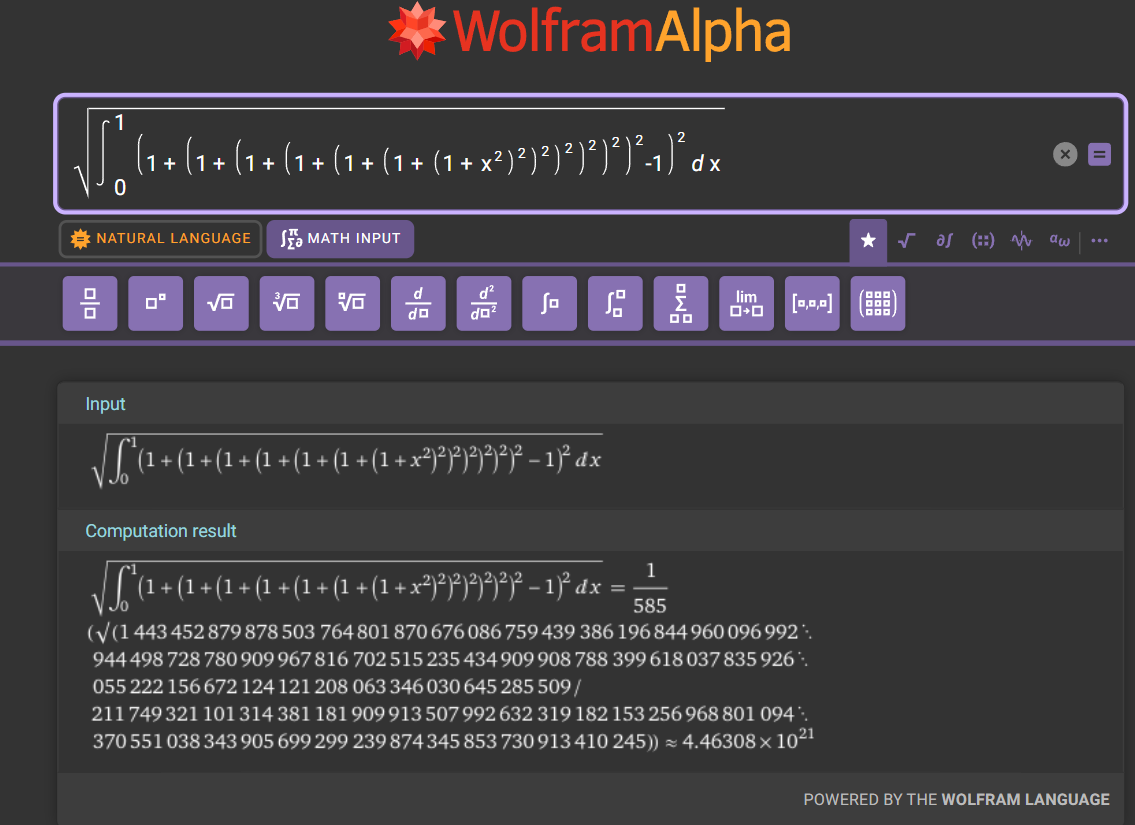

In [587]:
b.l2_metric_with_1()

4.463077479281998e+21

In [588]:
b = PolynomialCoefsMod2(2., offset=1000)
print(b)
b.l2_metric_with_1()

2.0x^1000


0.9989994994993742

In [589]:
b = PolynomialCoefsMod2(*([0.1] * 100), offset=10)
b <<= 2
print(b)
b.l2_metric_with_1()

1.0000000000000012e-11x^100+1.0000000000000012e-10x^102+5.500000000000007e-10x^104+2.2000000000000027e-09x^106+7.150000000000007e-09x^108+2.002000000000002e-08x^110+5.005000000000005e-08x^112+1.1440000000000011e-07x^114+2.4310000000000026e-07x^116+4.862000000000005e-07x^118+9.237801000000009e-07x^120+1.6796012000000014e-06x^122+2.9393078000000024e-06x^124+4.974236400000005e-06x^126+8.172036500000009e-06x^128+1.3075476800000013e-05x^130+2.0430987600000022e-05x^132+3.1248682400000015e-05x^134+4.687580820000004e-05x^136+6.908579600000005e-05x^138+0.0001001853216010001x^140+0.00014314204321400016x^142+0.00020173595790500017x^144+0.0002807376149600003x^146+0.00038611674238000034x^148+0.0005252851845680005x^150+0.000707378416632001x^152+0.0009435802955200014x^154+0.0012474961324900015x^156+0.0016355796274200019x^158+0.0021276196955660126x^160+0.0027472937441441634x^162+0.0035227945223013655x^164+0.004487538276608167x^166+0.005680962598338767x^168+0.007149423051915047x^170+0.00894719842965765

inf

In [590]:
b = PolynomialCoefsMod2(*([0.1] * 100), offset=10)
b <<= 2
print(b)
b(1)

1.0000000000000012e-11x^100+1.0000000000000012e-10x^102+5.500000000000007e-10x^104+2.2000000000000027e-09x^106+7.150000000000007e-09x^108+2.002000000000002e-08x^110+5.005000000000005e-08x^112+1.1440000000000011e-07x^114+2.4310000000000026e-07x^116+4.862000000000005e-07x^118+9.237801000000009e-07x^120+1.6796012000000014e-06x^122+2.9393078000000024e-06x^124+4.974236400000005e-06x^126+8.172036500000009e-06x^128+1.3075476800000013e-05x^130+2.0430987600000022e-05x^132+3.1248682400000015e-05x^134+4.687580820000004e-05x^136+6.908579600000005e-05x^138+0.0001001853216010001x^140+0.00014314204321400016x^142+0.00020173595790500017x^144+0.0002807376149600003x^146+0.00038611674238000034x^148+0.0005252851845680005x^150+0.000707378416632001x^152+0.0009435802955200014x^154+0.0012474961324900015x^156+0.0016355796274200019x^158+0.0021276196955660126x^160+0.0027472937441441634x^162+0.0035227945223013655x^164+0.004487538276608167x^166+0.005680962598338767x^168+0.007149423051915047x^170+0.00894719842965765

1.0101010101010851e+207

In [591]:
a = PolynomialCoefsMod2(
 1.19442236e-010, 3.81314021e-010, 1.20333070e-011, 3.82904734e-011,
 4.06232974e-011, 4.26609324e-014, 6.89648976e-014, 4.78705812e-014,
 9.53838768e-015, 1.02496744e-014, 4.99141864e-015, 5.76831382e-016,
 4.58867231e-016, 1.62253209e-016, 3.21975003e-020, 2.18783472e-020,
 8.47570472e-021, 2.44302235e-021, 1.35625277e-021, 4.10340288e-022,
 7.52575326e-023, 3.49272287e-023, 8.22221881e-024, 7.03981152e-025,
 3.21404921e-025, 1.00988354e-025, 3.07928275e-026, 1.19111026e-026,
 2.88706315e-027, 5.92762643e-028, 1.94744930e-028, 3.44811509e-029,
 3.18615538e-030, 1.14892322e-030, 3.24204131e-031, 9.39766707e-032,
 2.85252376e-032, 5.98777155e-033, 1.18430583e-033, 2.89908219e-034,
 3.41879491e-035, 1.18751730e-038, 3.73934474e-039, 1.01963557e-039,
 2.87149144e-040, 7.83344071e-041, 1.75459794e-041, 4.17636407e-042,
 1.06173769e-042, 2.25688962e-043, 5.46813207e-044, 1.54015847e-044,
 3.92811452e-045, 1.01035365e-045, 2.42213900e-046, 4.98780278e-047,
 1.07650363e-047, 2.34105436e-048, 4.38638002e-049, 9.64527343e-050,
 2.48178504e-050, 5.90951973e-051, 1.38297641e-051, 2.94453129e-052,
 5.47352872e-053, 1.03306691e-053, 1.85474277e-054, 2.80663926e-055,
 5.39315005e-056, 1.36773964e-056, 3.33543057e-057, 8.05038810e-058,
 1.85580060e-058, 4.17382716e-059, 9.73477414e-060, 2.25880760e-060,
 5.21493475e-061, 1.24954205e-061, 2.94170468e-062, 6.64841133e-063,
 1.46245599e-063, 3.04526072e-064, 6.17291352e-065, 1.28450207e-065,
 2.65595869e-066, 5.54135936e-067, 1.22024389e-067, 2.65634183e-068,
 5.49776181e-069, 1.08306262e-069, 1.97498366e-070, 3.42635087e-071,
 5.97934127e-072, 1.03386279e-072, 1.90104304e-073, 4.13249553e-074,
 9.54744094e-075, 2.16991189e-075, 4.87054799e-076, 1.07918666e-076,
 2.40033944e-077, 5.37370820e-078, 1.19449210e-078, 2.64206936e-079,
 5.78088064e-080, 1.23022537e-080, 2.54861542e-081, 5.15256812e-082,
 1.01974030e-082, 2.01897431e-083, 4.02664071e-084, 7.99772544e-085,
 1.58761085e-085, 3.11148390e-086, 5.81614690e-087, 1.01837676e-087,
 1.64202470e-088, 2.37696575e-089, 3.06642262e-090, 3.39270208e-091,
 2.73079016e-092, 1.16470822e-093, 2.49773816e-095, 5.54998500e-096,
 1.22513324e-096, 2.69157910e-097, 5.89958193e-098, 1.29278062e-098,
 2.82040408e-099, 6.10167590e-100, 1.30765351e-10, offset=1)
a.l2_metric_with_1(1)

1.0

## Body

In [592]:
def create_pol_by_odd_coefs(odd_coefs: Iterable[float], max_x=1.):
    return PolynomialCoefsMod2(*odd_coefs, max_x=max_x, offset=1)

In [593]:
def pol(odd_coefs: Iterable[float | int], max_x=1.):
    p = create_pol_by_odd_coefs(odd_coefs, max_x)
    return p

In [594]:
a = pol([1.00,1.00,0])
a

1.0x+1.0x^3

In [595]:
a <<= 2
a

1.0x+2.0x^3+3.0x^5+3.0x^7+1.0x^9

In [596]:
a <<= 2
a

1.0x+4.0x^3+18.0x^5+78.0x^7+315.0x^9+1182.0x^11+4107.0x^13+13215.0x^15+39375.0x^17+108768.0x^19+279168.0x^21+667440.0x^23+1489788.0x^25+3109888.0x^27+6077460.0x^29+11122452.0x^31+19056411.0x^33+30540060.0x^35+45723258.0x^37+63851670.0x^39+83027583.0x^41+100339254.0x^43+112469499.0x^45+116666343.0x^47+111716316.0x^49+98469000.0x^51+79621704.0x^53+58826280.0x^55+39520584.0x^57+24001704.0x^59+13083192.0x^61+6344568.0x^63+2707353.0x^65+1002708.0x^67+316746.0x^69+83430.0x^71+17775.0x^73+2934.0x^75+351.0x^77+27.0x^79+1.0x^81

In [597]:
def sign_l2_loss(f: PolynomialCoefsMod2, interval:list[float]=[0,1]):
    assert len(interval) == 2, "Интервал это 2 числа."
    left, right = interval
    assert left < right
    try:
        assert left == 0
        return f.l2_metric_with_1(right)
    except OverflowError:
        return float('+inf')
    

In [598]:
def sign_max_loss(f: Callable, interval=[0,1], h=1e-5):
    assert len(interval) == 2, "Интервал это 2 числа."
    left, right = interval
    assert left < right    
    n_steps = int((right - left) / h)
    assert n_steps != 0, "Слишком маленький интервал по сравнению с шагом"
    try:
        x = left
        ans = abs(f(x))
        for _ in range(1, n_steps):
            x += h
            delta = abs(f(x)-1)
            if math.isnan(delta):
                return float('+inf')
            ans = max(ans, delta)
        return ans
    except OverflowError:
        return float('+inf')

In [599]:
def repeat(f: PolynomialCoefsMod2, n: int):
    f <<= n
    return f

In [600]:
def NewtonS(odd_coefs: list, n: int, max_x: float):
    f = pol(odd_coefs, max_x)
    f = repeat(f, n)
    return f

In [601]:
def abstruct_objective(coef_len: int, max_x: float, n: int, metric='l2'):
    def objective(trial: optuna.Trial):
        odd_coefs = []
        for i in range(coef_len):
            odd_coefs.append(
                trial.suggest_float(f"a{i}", -10, 10)
            )
        f = NewtonS(odd_coefs, n, max_x)
        loss = float('+inf')
        if metric == 'l2':
            loss = sign_l2_loss(f, [0, max_x])
        elif metric == 'max':
            loss = sign_max_loss(f, [0, max_x], max_x / 5e3)
        return loss
    return objective

In [602]:
def experiment(coef_len: int, max_x: float, n: int, metric='l2', n_trials=100):
    filename = f"sqlite:///analitical_optuna_solution/sampler_{coef_len}_{int(max_x)}_{n}_{metric}.db"
    sampler = optuna.samplers.CmaEsSampler()
    study = optuna.create_study(
        study_name=f"Study({coef_len},{int(max_x)},{n},{metric})",
        sampler=sampler,
        storage=filename,
        direction='minimize',
        load_if_exists=True,
    )
    study.optimize(
        abstruct_objective(
            coef_len,
            max_x, n, metric=metric),
        n_jobs = 1, timeout=30,
        show_progress_bar=True
    )
    # Save the sampler with pickle to be loaded later
    try:
        best_value = study.best_value
        best_params = study.best_params
    except ValueError:
        best_value = max_x
        best_params = {}

    return (coef_len, max_x, n, best_value, best_params)


In [603]:
results = []
breaks = 2
for coef_len in [3, 5, 7]:
    odd_coef_len = coef_len // 2 + 1
    for max_x in [1, 5, 10, 20]:
        for n in [5, 8]:
            if breaks > 0:
                breaks -= 1
                continue
            results.append(
                experiment(odd_coef_len, max_x, n, 'l2', n_trials=100)
            )

   0%|          | 00:00/00:30

coef = 0.0
x = 880525457171033456874745441674884170327054378514910892019489197387978571918594290050960406523930623031459968503339602543603822686916908040876096049635941765700962620319508187717117843561294365392952697140220821529551647054763400057439926315599826486642203086347316745054192299591022674576379358768463134765625
int too large to convert to float
5
offset=1


UnboundLocalError: cannot access local variable 'l2' where it is not associated with a value

In [ ]:
def get_df(results: list[tuple[int, float, int, float, dict[str, float]]]):
    coef_counts, max_xs, NSs, losses, ds = zip(*results)
    d_a1 = [d.get('a0', 0) for d in ds]
    d_a3 = [d.get('a1', 0) for d in ds]
    d_a5 = [d.get('a2', 0) for d in ds]
    d_a7 = [d.get('a3', 0) for d in ds]
    df = pd.DataFrame({
        "loss": losses,
        "coef_count": coef_counts,
        "max_x": max_xs,
        "NS_n": NSs,
        "a1": d_a1,
        "a3": d_a3,
        "a5": d_a5,
        "a7": d_a7,
    })
    return df

In [ ]:
df = get_df(results)
df

,loss,coef_count,max_x,NS_n,a1,a3,a5,a7
0,0.0,2,5,5,0.866838,-0.01294,0,0


In [ ]:
sorted_colnames = ['coef_count', 'max_x', 'NS_n']
df_multi = df.set_index(sorted_colnames)
df_multi.reset_index(sorted_colnames)

,coef_count,max_x,NS_n,loss,a1,a3,a5,a7
0,2,5,5,0.0,0.866838,-0.01294,0,0


In [ ]:
import os


sorted_colnames = ['coef_count', 'max_x', 'NS_n']

if os.path.exists(SAVE_FILENAME):
    # Загружаем существующий файл
    old_df = pd.read_csv(SAVE_FILENAME, index_col=False)
    # Убедимся, что индекс уникален и состоит из ключевых столбцов
    old_df = old_df.drop_duplicates(subset=sorted_colnames, keep='first')  # на случай дубликатов

    # Объединяем старые и новые данные по ключу
    df = df.drop_duplicates(subset=sorted_colnames, keep='first')

    # Объединяем с помощью merge, чтобы сравнить loss
    merged = pd.merge(
        old_df,
        df,
        on=sorted_colnames,
        how='outer',
        suffixes=('_old', '_new'),
        indicator=True
    )

    # Случай 1: только в новых данных → добавить
    only_new = merged[merged['_merge'] == 'right_only'].copy()
    only_new = only_new.rename(columns={col + '_new': col for col in df.columns if col not in sorted_colnames})
    only_new = only_new[df.columns]  # сохраняем порядок столбцов

    # Случай 2: только в старых → оставить
    only_old = merged[merged['_merge'] == 'left_only'].copy()
    only_old = only_old.rename(columns={col + '_old': col for col in old_df.columns if col not in sorted_colnames})
    only_old = only_old[old_df.columns]

    # Случай 3: есть и там, и там → выбрать с меньшим loss
    both = merged[merged['_merge'] == 'both'].copy()
    # Заменяем inf на np.inf, если ещё не так
    loss_old = pd.to_numeric(both['loss_old'], errors='coerce').fillna(np.inf)
    loss_new = pd.to_numeric(both['loss_new'], errors='coerce').fillna(np.inf)

    # Выбираем строки, где loss_new лучше (меньше или равен, но обычно — меньше)
    better_new = loss_new < loss_old  # inf < inf → False, inf < 5 → False, 3 < inf → True — всё верно

    # Формируем обновлённые строки
    updated_rows = both.copy()
    for col in df.columns:
        if col in sorted_colnames:
            continue
        # Берём значение из новой строки, если она лучше; иначе — из старой
        updated_rows[col] = np.where(better_new, both[col + '_new'], both[col + '_old'])

    # Убираем суффиксы и лишние столбцы
    final_both = updated_rows[old_df.columns]

    # Собираем финальный DataFrame
    final_df = pd.concat([only_old, only_new, final_both], ignore_index=True)

    # Сохраняем
    os.remove(SAVE_FILENAME)
    final_df.to_csv(SAVE_FILENAME, index=False)
    df = final_df

    # Определяем статус
    if len(only_new) > 0 or better_new.any():
        print("GOOD UPDATE")
    else:
        print("BAD UPDATE")

else:
    # Файл не существует — просто сохраняем
    df.to_csv(SAVE_FILENAME, index=False)
    print("SAVE")

GOOD UPDATE


$${\cal E}(\theta)=\int$$
$$\int_0^l(\text{sign}(x)-p_{\theta}(x))^2dx=\int_0^l(1-p_{\theta}(x))^2dx=l+\sum_{i=0}^{2k} b_{\theta, i}\frac{l^{2i}}{2i}$$

In [604]:
df = get_df(results)
df

ValueError: not enough values to unpack (expected 5, got 0)

In [ ]:
def plots(df: pd.DataFrame, max_x = 1, alpha=0.5):
    max_x_per_cent = 100 * max_x
    for n_row, row in df[df['max_x'] == max_x].iterrows():
        f = NewtonS([row[f'a{i}']for i in range(1, 8, 2)], int(row['NS_n']))
        print(f)
        print(f(0), len(f), f.l2_metric_with_1(max_x))
        x_es = [i/100 for i in range(max_x_per_cent)]
        y_es: list = [f(i/100) for i in range(max_x_per_cent)]
        if max(*y_es) > 10 or min(*y_es) < -10:
            continue
        plt.plot(x_es, y_es, label=n_row, alpha=alpha)
    plt.legend()
    plt.show()

5.079902888235518x+-26.56241426902045x^3+137.6295717059586x^5+-603.4097034436749x^7+2263.316058050441x^9+-7408.353172235118x^11+21534.895219360686x^13+-56392.247037652116x^15+134569.1821803631x^17+-295340.28056740557x^19+600563.4781129985x^21+-1138248.635975659x^23+2020470.4208377302x^25+-3372283.941286728x^27+5309869.907409468x^29+-7909427.911493232x^31+11172609.236310832x^33+-14997932.39039594x^35+19168763.03320655x^37+-23365813.373494726x^39+27205926.311378445x^41+-30300999.414979413x^43+32324115.748785015x^45+-33066916.78811747x^47+32474227.9207987x^49+-30648248.104168892x^51+27822961.570163783x^53+-24316949.933784712x^55+20477181.440160796x^57+-16626697.691046825x^59+13025966.837380443x^61+-9852608.726538677x^63+7199069.725765867x^65+-5084063.598302333x^67+3471851.0735948533x^69+-2293584.1889425507x^71+1466367.955369552x^73+-907614.8046437755x^75+544041.2129394889x^77+-315908.7381446921x^79+177748.84371950506x^81+-96932.97938266424x^83+51244.795930695334x^85+-26267.90520810595x^87

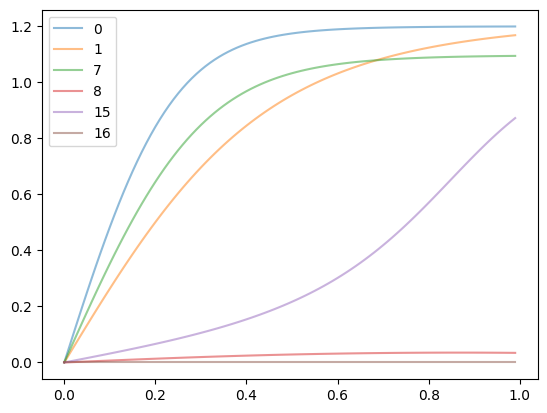

In [ ]:
plots(df)

0.00037681972410249544x+7.895331164737635e-05x^3+6.068944913491765e-06x^5+1.1826087309310688e-06x^7+1.0689942331617189e-07x^9+9.158928880763147e-09x^11+1.3275572701414987e-09x^13+1.6158065910749894e-10x^15+1.8667314836873653e-11x^17+1.9225846349890887e-12x^19+1.8636145685480437e-13x^21+1.9265016798064843e-14x^23+2.0637701010690982e-15x^25+2.318248134764943e-16x^27+2.709754101892539e-17x^29+3.134890674896752e-18x^31+3.55322614021896e-19x^33+3.955830741782874e-20x^35+4.335505477687326e-21x^37+4.684377964181937e-22x^39+4.988836270445865e-23x^41+5.2527337411570115e-24x^43+5.495667521396887e-25x^45+5.744473731172287e-26x^47+6.029580670039013e-27x^49+6.3758690680300905e-28x^51+6.801127108651917e-29x^53+7.318819587392403e-30x^55+7.94025493896802e-31x^57+8.676728678365161e-32x^59+9.537653763312178e-33x^61+1.0527328054457748e-33x^63+1.1644081236824794e-34x^65+1.2881309652412873e-35x^67+1.422991312424493e-36x^69+1.568103013569106e-37x^71+1.7227765035587864e-38x^73+1.88656406037145e-39x^75+2.0592

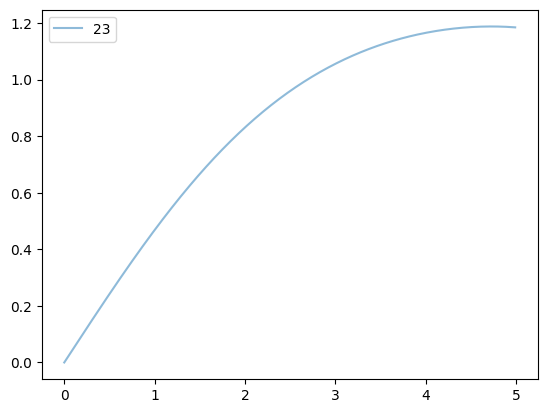

In [ ]:
plots(df, max_x=5)

In [ ]:
def plots_minimum(df: pd.DataFrame, n_points: int = 100):
    min_loss = df[df['loss'] != 0.0]['loss'].min()
    row: pd.DataFrame = df[df['loss'] == min_loss]
    max_x = row['max_x'].iloc[0]
    f = NewtonS([row[f'a{i}'].iloc[0] for i in range(1, 8, 2)], int(row['NS_n'].iloc[0]))
    x_es = [i/n_points for i in range(max_x * n_points)]
    y_es: list = [f(i/n_points) for i in range(max_x * n_points)]
    plt.plot(x_es, y_es)
    plt.show()
    return f

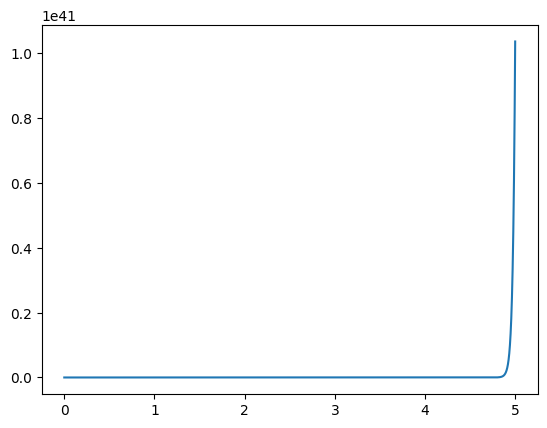

In [ ]:
f = plots_minimum(df, 10000)

In [ ]:
f.l2_metric_with_1()

0.9997906895343875

In [ ]:
bestf = NewtonS([0.8668380313786912,-0.01294046503009838], 5)
bestf.l2_metric_with_1()

0.7726994900990123

In [ ]:
bestf(0.3)

0.14622810657192367

In [ ]:
sign_l2_loss(NewtonS([0.8668380313786912,-0.01294046503009838], 5), [0, 5])

0.0